In [57]:
# Theoretical and Real AVO analysis using raw seismic data from KOPRI
# Zachary Katz
# 27 November 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from scipy.signal import find_peaks
import scipy

############
line = '21X'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 20 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]
    

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data

    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords

# Make theoretical AVO curves
def Aki_Richards_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1

    term1 = 0.5 * ( 1 + np.tan(thetas)*np.tan(thetas)) * delta_p / p
    term2 = (4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas) * delta_s / s)
    term3 = 0.5 * ( 1 -4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas))* delta_rho / rho

    return term1 - term2 + term3

def Shuey_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1
    
    R0 = 0.5 * (delta_p / p + delta_rho / rho)
    k = (s / p) ** 2
    G = 0.5 * (delta_p / p) - 2.0 * k * (delta_rho / rho + 2.0 * delta_s / s)
    F = 0.5 * (delta_p / p)
    R = R0 + G * np.sin(thetas)**2 + F * (np.tan(thetas)**2 - np.sin(thetas)**2)
    return R, R0, G


# Ice properties for theoretical curves
alpha_Ice = 3810
beta_Ice = 1860
rho_Ice =  920

materials = {
    "Water": {
        "alpha": 1500,
        "beta": 0,
        "rho": 997,
    },
    "Basement": {
        "alpha": 5200,
        "beta": 2800,
        "rho": 2700,
    },
    "Stiff": {
        "alpha": 1800,
        "beta": 1000,
        "rho": 1900,
    },
    "Dilatant": {
        "alpha": 1700,
        "beta": 200,
        "rho": 1800,
    },
    "Lithified": {
        "alpha": 3750,
        "beta": 2450,
        "rho": 2450,
    },
}


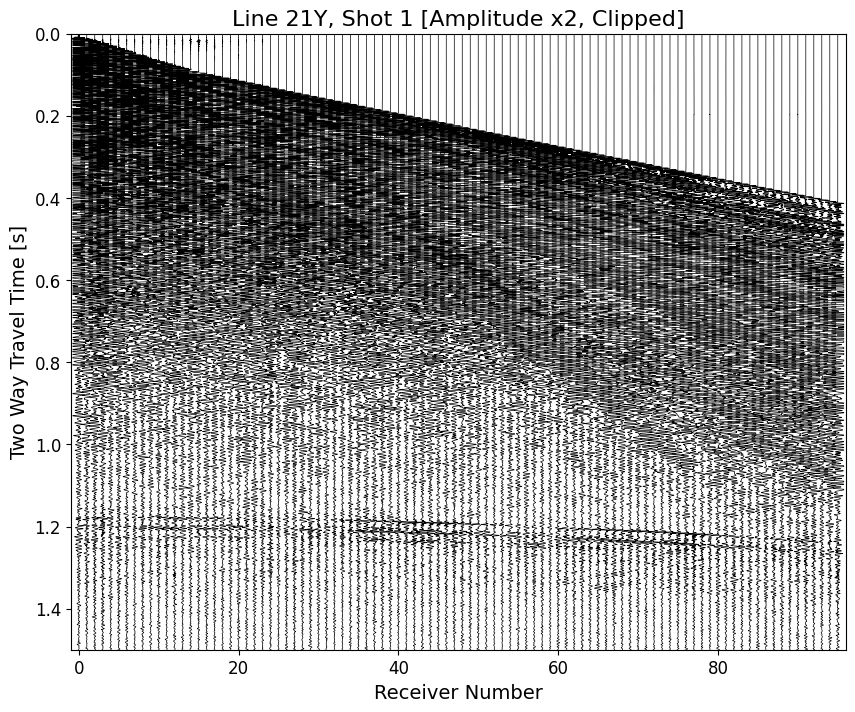

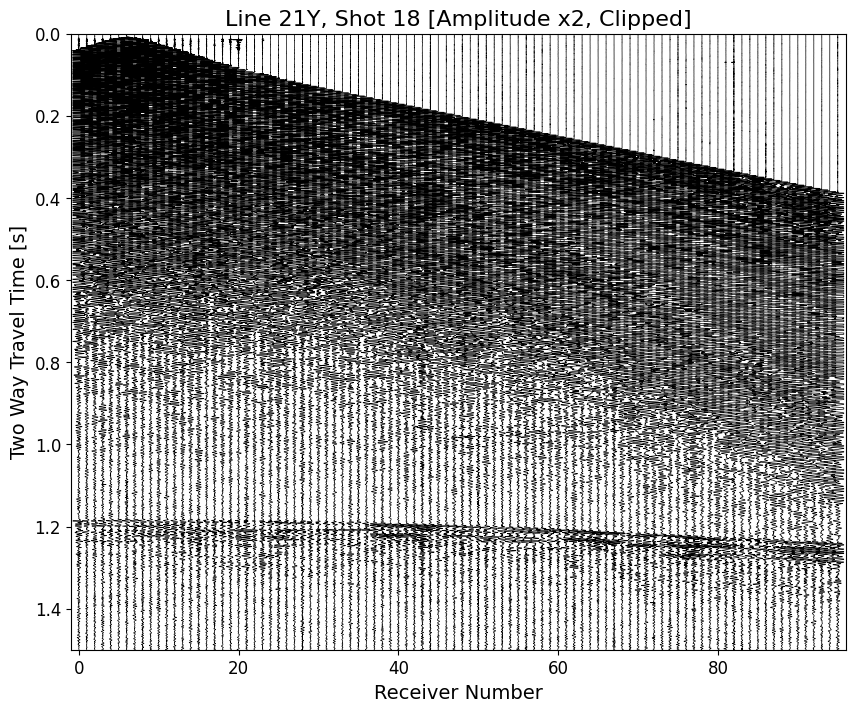

In [35]:
# Full shot as an example for PPT
for index, fldr_number in enumerate([1,18]):
    fig, ax = plt.subplots(figsize=(10, 8))
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    traces = data_clipped
    for trace_no, trace in enumerate(traces.T):
        trace = trace * 2
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5)

    ax.set_ylim(1.5,0)
    ax.set_xlim(-1, n_traces)
    #ax.set_ylim(1.5,1)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number} [Amplitude x2, Clipped]",fontsize=16)
    ax.tick_params(labelsize=12)

In [58]:
# Load picks from KOPRI

excel_path = f'./_data/7_AVO/AVO_{line}.xlsx'
picks_df = pd.read_excel(excel_path)
picks_df.head()

,TRACE_SEQ_NO,SHOT_POINT_NO,CHANNEL_NO,OFFSET_SH_REC,Angle,TWT1_ms,Amplitude1,TWT2_ms,Amplitude2
0,1,2,1,-90,2.343591,1186.00,-0.019,-9999.0,-9999.0
1,2,2,2,-75,1.953076,1184.25,-0.018,-9999.0,-9999.0
2,3,2,3,-60,1.562515,1184.50,-0.038,-9999.0,-9999.0
3,4,2,4,-45,1.171918,1184.25,-0.078,-9999.0,-9999.0
4,5,2,5,-30,0.781294,1184.00,-0.085,-9999.0,-9999.0


In [59]:

arr = picks_df.loc[picks_df["SHOT_POINT_NO"] == fldr_number, ["CHANNEL_NO", "TWT1_ms"]].to_numpy()
arr

array([[ 1.00000e+00,  1.18250e+03],
       [ 2.00000e+00,  1.18200e+03],
       [ 3.00000e+00,  1.18175e+03],
       [ 4.00000e+00,  1.18150e+03],
       [ 5.00000e+00,  1.18125e+03],
       [ 6.00000e+00,  1.18125e+03],
       [ 7.00000e+00,  1.18100e+03],
       [ 8.00000e+00,  1.18100e+03],
       [ 9.00000e+00,  1.18075e+03],
       [ 1.00000e+01,  1.18050e+03],
       [ 1.10000e+01,  1.18000e+03],
       [ 1.20000e+01,  1.17975e+03],
       [ 1.30000e+01,  1.17950e+03],
       [ 1.40000e+01,  1.17925e+03],
       [ 1.50000e+01,  1.17900e+03],
       [ 1.60000e+01,  1.17875e+03],
       [ 1.70000e+01,  1.17850e+03],
       [ 1.80000e+01,  1.17850e+03],
       [ 1.90000e+01,  1.17825e+03],
       [ 2.00000e+01,  1.17800e+03],
       [ 2.10000e+01,  1.17800e+03],
       [ 2.20000e+01,  1.17775e+03],
       [ 2.30000e+01,  1.17775e+03],
       [ 2.40000e+01,  1.17775e+03],
       [ 2.50000e+01,  1.17750e+03],
       [ 2.60000e+01,  1.17750e+03],
       [ 2.70000e+01,  1.17725e+03],
 

In [ ]:
# Plot wiggle plots
#for fldr_number in  np.arange(1,num_shots +1):
for fldr_number in np.arange(15,20):
    # Load data
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    assert len(subset_geometry['XSHOT']) == len(data_clipped[0]), "Incorrect length of shot data vs geometry file"

    # Calculate offset angles
    z = 2250 # Assume constant depth
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    offset_angle = np.rad2deg(np.arctan2(dist, z))

    # Pick, plot and save peaks for each of the 96 traces recorded for each SHOT
    # For trace in the 96 traces, get the amplitude of the first reflection

    fig, ax = plt.subplots(figsize=(10, 8))
    st_time = 1.0
    et_time = 1.3

    # slice indices
    i1 = np.searchsorted(time, st_time)
    i2 = np.searchsorted(time, et_time)

    data_win = data_clipped[i1:i2, :]
    time_win = time[i1:i2]

    extent = [0, n_traces, time_win[-1], time_win[0]]

    traces = data_clipped
    for trace_no, trace in enumerate(traces.T):
        trace = trace * 3
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5,zorder=5)

    ax.set_xlim(-1, n_traces)       # traces 0..N
    ax.set_ylim(et_time + 0.1, st_time - 0.15)  # flip time axis (deeper at bottom)

    # Plot picks from KOPRI
    pick_arr = picks_df.loc[picks_df["SHOT_POINT_NO"] == fldr_number, ["CHANNEL_NO", "TWT1_ms"]].to_numpy()
    ax.scatter(
        pick_arr[:, 0] - 1,  # CHANNEL_NO starts at 1
        pick_arr[:, 1] / 1000,  # Convert ms to s
        color='red',marker='_',zorder=2,label='KOPRI Picks',alpha=0.7)
    
    #print(first_peak_amp)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number}",fontsize=16)
    ax.tick_params(labelsize=12)
    ax.legend(loc='upper right')


        

In [60]:
# Plot example amplitude plots

offset_angle_all = []
peak_amp_all = []
ran_fldr_numbers = []

for fldr_number in  np.arange(1,num_shots +1):
    # Load data
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    assert len(subset_geometry['XSHOT']) == len(data_clipped[0]), "Incorrect length of shot data vs geometry file"

    # Calculate offset angles
    z = 2250 # Assume constant depth
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    offset_angle = np.rad2deg(np.arctan2(dist, z))

    # Pick, plot and save peaks for each of the 96 traces recorded for each SHOT
    # For trace in the 96 traces, get the amplitude of the first reflection

    fig, ax = plt.subplots(figsize=(5, 5))
    if fldr_number < 13:
        st_time = 1.15
        et_time = 1.3
    else:
        st_time = 1.0
        et_time = 1.15

    # slice indices
    i1 = np.searchsorted(time, st_time)
    i2 = np.searchsorted(time, et_time)

    data_win = data_clipped[i1:i2, :]
    time_win = time[i1:i2]

    extent = [0, n_traces, time_win[-1], time_win[0]]

    st_p_time = 1
    et_p_time = 1.4
    ip1 = np.searchsorted(time, st_p_time)
    ip2 = np.searchsorted(time, et_p_time)
    data_p_win = data_clipped[ip1:ip2, :]
    time_p_win = time[ip1:ip2]

    extent = [0, n_traces, time_p_win[-1], time_p_win[0]]


    im = ax.imshow(
        data_p_win,
        cmap='seismic',
        interpolation='none',
        aspect='auto',
        extent=extent,
        vmin=-1, vmax=1
    )


    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Amplitude (normalized)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    peak_indices_per_trace = [] # Save all peaks
    peak_props_per_trace = [] # Save all peak properties
    first_peak_time = np.full(data_clipped.shape[1], np.nan) # Save first peak
    first_peak_amp = np.full(data_clipped.shape[1], np.nan)   # Save first peak amplitude

    first_peak_1_shot = []
    offset_angle_1_shot = []
    for trace_idx in range(data_clipped.shape[1]):
        trace = data_win[:, trace_idx]
        trace = -trace

        # Find peaks — add parameters as needed (height, distance, prominence…)
        #peaks, props = find_peaks(trace, prominence=0.1, distance=10, height=0.1)
        peaks, props = find_peaks(trace, prominence=0.15, distance=100, height=0.13)

        if len(peaks) > 0:
            first_idx = peaks[0]          # earliest (shallowest) peak
            first_peak_amp[trace_idx] = -trace[first_idx] # Looking at minima still
            first_peak_time[trace_idx] = time_win[first_idx]

        peak_indices_per_trace.append(peaks)
        peak_props_per_trace.append(props)

        first_peak_1_shot.append(first_peak_amp)
        offset_angle_1_shot.append(offset_angle)

    #print(first_peak_time)
    #print(first_peak_amp)

    peak_times = [time[peaks] for peaks in peak_indices_per_trace]
    peak_amps = [-data_clipped[peaks, tr] for tr, peaks in enumerate(peak_indices_per_trace)]

    for tr, peaks in enumerate(peak_indices_per_trace):
        if tr == 0:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='green',marker='_',zorder=2,label='Picked Peaks')
        else:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='green',marker='_',zorder=2)
   
    ax.scatter(np.arange(data_clipped.shape[1]),first_peak_time, color='black',marker="_",zorder=3, label='First Pick')
    #print(first_peak_amp)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number}",fontsize=16)
    ax.tick_params(labelsize=12)
    ax.legend(loc='lower right')

    offset_angle_all.append(offset_angle_1_shot)
    peak_amp_all.append(first_peak_1_shot)
    ran_fldr_numbers.append(fldr_number)
    

        

ValueError: No traces found for fldr=1

Water: R0=-0.395, G=0.527
Basement: R0=0.646, G=-0.804
Stiff: R0=-0.011, G=-0.094
Dilatant: R0=-0.059, G=0.337
Lithified: R0=0.446, G=-0.954


Text(1, 0.91, '21X')

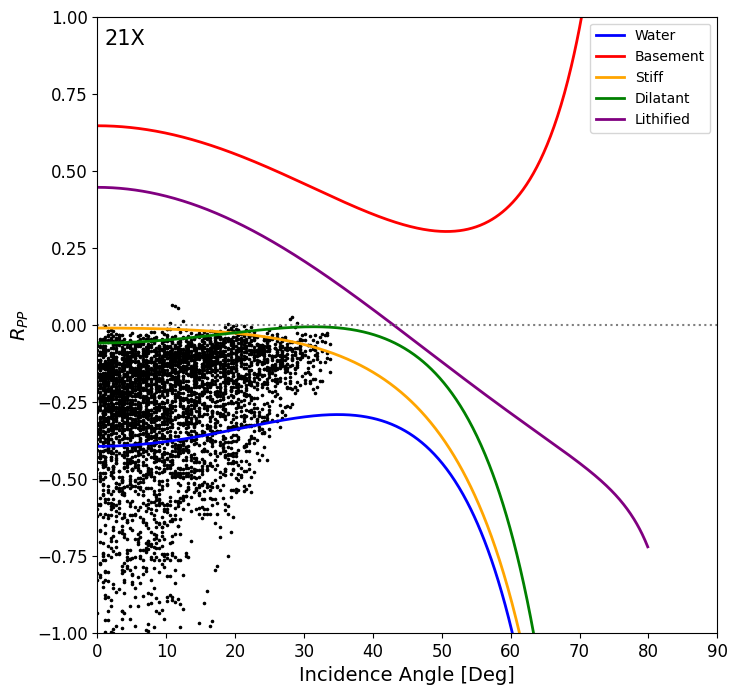

In [64]:
# Plot theoretical curves and data points
angles = np.arange(0, 80, 0.1)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R, R0, G = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name, linewidth=2)
    ax.legend()
    print(f"{name}: R0={R0:.3f}, G={G:.3f}")
ax.set_ylim(-1,1)
ax.set_xlim(0,90)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$',fontsize=14)
ax.set_xlabel('Incidence Angle [Deg]',fontsize=14)
ax.tick_params(labelsize=12)


ax.scatter(picks_df["Angle"], picks_df["Amplitude1"], color='black',marker='.',s=10)
ax.text(1, 0.91, f'{line}', fontsize=15, color='black')

In [76]:
# Create linear regression fit
plot = False
bins = 0
regressions = {'slope':[], 'intercept':[]}
ran_fldr_numbers = range(2, np.max(picks_df["SHOT_POINT_NO"])+1)
for fldr_number in ran_fldr_numbers:
    print(fldr_number)
    offset_angle = picks_df.loc[picks_df["SHOT_POINT_NO"] == fldr_number, "Angle"].to_numpy()
    amp = picks_df.loc[picks_df["SHOT_POINT_NO"] == fldr_number, "Amplitude1"].to_numpy()
    if len(amp) > 0:
        bins = bins+1
        # Mask to exlude -9999 fill values
        mask = amp != -9999
        offset_angle = offset_angle[mask]
        amp = amp[mask]

        sin_2_angle = np.sin(np.deg2rad(offset_angle))**2

        #slope, intercept = np.polyfit(sin_2_angle[mask], first_peak_amp[0][mask], 1) #Offset angle is nested list but identical for each
        res = scipy.stats.linregress(sin_2_angle, amp)

        slope = res.slope
        intercept = res.intercept
        r2 = res.rvalue**2
        regressions['slope'].append(slope)
        regressions['intercept'].append(intercept)

        print(slope, intercept)
        if plot:
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.scatter(sin_2_angle, amp, color='gray',marker='.',s=10)
            # Plot lin regression
            x_vals = np.linspace(0, np.max(sin_2_angle), 100)
            y_vals = intercept + slope * x_vals
            ax.plot(x_vals, y_vals, color='red', linewidth=2, label=f'y={slope:.2f}x + {intercept:.2f}, $R^2$={r2:.2f}')
            ax.set_xlabel(r'$\sin^2(\theta)$', fontsize=14)
            ax.set_ylabel(r'$A$', fontsize=14)
            ax.legend(fontsize=14, loc='lower left')
            ax.set_title(f'Line {line}, Shot {fldr_number}', fontsize=16)
            ax.tick_params(labelsize=12)


        
        

2
-0.00026456538457336694 -0.12228498225261039
3
0.11548299819883746 -0.13749145347418926
4
0.26102992496311833 -0.13782838959993618
5
0.3251718978508441 -0.16615376769486717
6
0.29124390809572487 -0.18135532388000383
7
0.2873722414499501 -0.21158492051680827
8
0.4221260548004113 -0.22886125200931023
9
0.16961765686463143 -0.29850354559894693
10
0.48120146190756263 -0.3302086901275072
11
0.9701070982658737 -0.32618934501691577
12
0.8266881822627561 -0.23378418690631464
13
0.9138608214848407 -0.1855916377952339
14
2.0398044543031957 -0.24100887301714174
15
2.0176700363367224 -0.26404115207335993
16
0.719187815674306 -0.28011507537777514
17
0.5017633626133641 -0.2874954407356985
18
0.6433445585726519 -0.24845666794632115
19
1.4046799324021082 -0.41865830528689657
20
1.9349386254370697 -0.5331401447500033
21
2.9285316394651604 -0.673424902096863
22
2.8167623974624205 -0.6412984039963494
23
1.5631079942024515 -0.6847886521004176
24
-3.030216239378662 -0.45236446953261644
25
26
1.9820737715

/tmp/ipykernel_15103/4276529200.py:20: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = scipy.stats.linregress(sin_2_angle, amp)


/tmp/ipykernel_15103/1050677163.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", N)


(-4.0, 4.0)

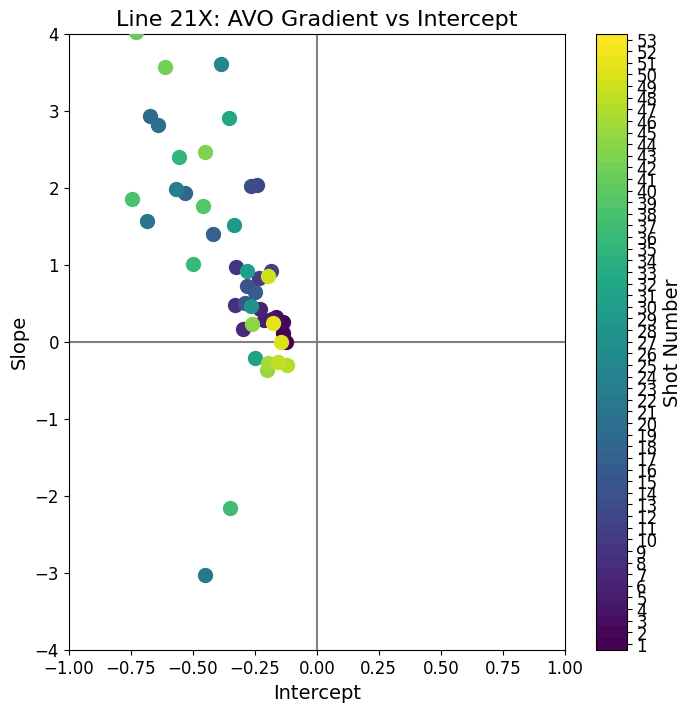

In [77]:
# Scatter plot

vals = np.asarray(ran_fldr_numbers)
N = bins # Bins

# Normalize for colormap (maps min→0, max→1)
norm = plt.Normalize(vals.min(), vals.max())
cmap = plt.cm.get_cmap("viridis", N)

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0, color='gray', linestyle='-')
ax.axvline(0, color='gray', linestyle='-')
# Scatter slope, intercept, color is shot color viridis
for ran_fldr_number, slope, intercept in zip(ran_fldr_numbers, regressions['slope'], regressions['intercept']):
    color = cmap(norm(ran_fldr_number))
    ax.scatter(intercept, slope, color=color, marker='o', s=100,zorder=3)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Shot Number', fontsize=14)
cbar.ax.tick_params(labelsize=12)
bin_edges = np.linspace(vals.min(), vals.max(), N + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
cbar.set_ticks(bin_centers)
cbar.set_ticklabels(np.arange(1, N + 1))


ax.set_ylabel('Slope', fontsize=14)
ax.set_xlabel('Intercept', fontsize=14)
ax.set_title(f'Line {line}: AVO Gradient vs Intercept', fontsize=16)
ax.tick_params(labelsize=12)

ax.set_xlim(-1, 1)
ax.set_ylim(-4, 4)
